<a href="https://colab.research.google.com/github/TommyyPasto/DLA-course-repo/blob/main/Lab%202/DLA_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this second laboratory we will gain some experience working with Transformer models for a variety tasks using (mostly) the Hugging Face Ecosystem.


---
### Exercise 1: Sentiment Analysis (warm up)

In this first exercise we will start from a pre-trained BERT transformer and build up a model able to perform text sentiment analysis. Transformers are complex beasts, so we will build up our pipeline in several explorative and incremental steps.

#### Exercise 1.1: Loading the Dataset Splits
There are a many sentiment analysis datasets, but we will use one of the smallest ones available: the [Cornell Rotten Tomatoes movie review dataset](https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes), which consists of 5,331 positive and 5,331 negative processed sentences from the Rotten Tomatoes movie reviews.

**Your first task**: Load the dataset and figure out what splits are available and how to get them. Spend some time exploring the dataset to see how it is organized. Note that we will be using the [HuggingFace Datasets](https://huggingface.co/docs/datasets/en/index) library for downloading, accessing, splitting, and batching data for training and evaluation.

In [ ]:
import torch

In [ ]:
# Dataset imports.
from datasets import load_dataset, get_dataset_split_names

# Your code here.
splits = get_dataset_split_names('cornell-movie-review-data/rotten_tomatoes')

README.md: 0.00B [00:00, ?B/s]

In [ ]:
# Load all splits into dict.
ds_dict = {split: load_dataset('cornell-movie-review-data/rotten_tomatoes', split=split) for split in splits}

train.parquet:   0%|          | 0.00/699k [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/90.0k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/92.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

In [ ]:
import numpy as np

ds_train = ds_dict['train']
for row in np.random.permutation(len(ds_train))[:10]:
    print(f'{ds_train[row]['label']}: {ds_train[row]['text']}')

1: there's . . . tremendous energy from the cast , a sense of playfulness and excitement that seems appropriate .
1: it is an indelible epic american story about two families , one black and one white , facing change in both their inner and outer lives .
1: combine the paranoid claustrophobia of a submarine movie with the unsettling spookiness of the supernatural -- why didn't hollywood think of this sooner ?
1: director alfonso cuaron gets vivid , convincing performances from a fine cast , and generally keeps things going at a rapid pace , occasionally using an omniscient voice-over narrator in the manner of french new wave films .
0: clockstoppers is one of those crazy , mixed-up films that doesn't know what it wants to be when it grows up .
1: [a] wonderfully loopy tale of love , longing , and voting .
0: . . . standard guns versus martial arts cliche with little new added .
1: it's technically sumptuous but also almost wildly alive .
0: this sort of cute and cloying material is far

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

# Costruisco un df con tutti gli split inclusi
dfs = []
for split_name, ds in ds_dict.items():
    tmp = ds.to_pandas()
    tmp['split'] = split_name
    dfs.append(tmp)
df_all = pd.concat(dfs, ignore_index=True)

print(df_all.groupby(['split', 'label']).size().unstack())

label          0     1
split                 
test         533   533
train       4265  4265
validation   533   533


#### il dataset sembra distribuito perfettamente in entrambe le classi, per ogni split

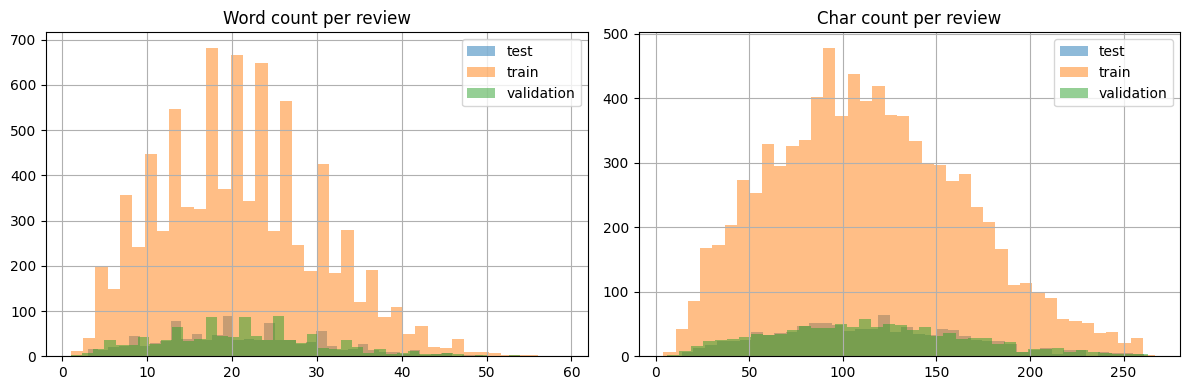

             count  mean  std  min   25%   50%   75%   max
split                                                     
test        1066.0  21.2  9.5  3.0  14.0  20.0  27.8  52.0
train       8530.0  21.0  9.4  1.0  14.0  20.0  27.0  59.0
validation  1066.0  21.0  9.6  1.0  14.0  21.0  27.0  54.0


In [ ]:
# distribuzione delle lunghezze delle recensioni
df_all['n_words'] = df_all['text'].apply(lambda x: len(x.split()))
df_all['n_chars'] = df_all['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for split_name, grp in df_all.groupby('split'):
    grp['n_words'].hist(bins=40, alpha=0.5, ax=axes[0], label=split_name)
    grp['n_chars'].hist(bins=40, alpha=0.5, ax=axes[1], label=split_name)

axes[0].set_title('Word count per review')
axes[1].set_title('Char count per review')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

print(df_all.groupby('split')['n_words'].describe().round(1))

#### Possiamo osservare una distribuzione gaussiana delle lunghezze delle frasi. La cosa risulta molto più marcata per il train set vista la grande superiorità di campioni rispetto a test e val.

#### DIamo ora un occhiata alle parole più frequenti per ogni classe di recensione(neg./pos.):

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

for lbl, lbl_name in [(0, 'negative'), (1, 'positive')]:
    subset = df_all[df_all['label'] == lbl]['text'].tolist()
    vec = CountVectorizer(stop_words='english', max_features=15)
    vec.fit(subset)
    freqs = vec.transform(subset).sum(axis=0).A1
    top = sorted(zip(vec.get_feature_names_out(), freqs), key=lambda x: -x[1])
    print(f"\nTop words [{lbl_name}]:", [w for w, _ in top])


Top words [negative]: ['movie', 'film', 'like', 'just', 'story', 'bad', 'time', 'good', 'comedy', 'characters', 'little', 'doesn', 'director', 'way', 'really']

Top words [positive]: ['film', 'movie', 'like', 'story', 'good', 'comedy', 'funny', 'time', 'best', 'life', 'way', 'director', 'love', 'characters', 'make']



---
### Exercise 1.2: A Pre-trained BERT and Tokenizer

The model we will use is a *very* small BERT transformer called [DistilBERT](https://huggingface.co/distilbert/distilbert-base-uncased) this model was trained (using self-supervised learning) on the same corpus as BERT but using the full BERT base model as a *teacher*.

**Your next task**: Load the DistilBERT model and corresponding tokenizer. Use the tokenizer on a few samples from the dataset and pass the tokens through the model to see what outputs are provided. I suggest you use the [`AutoModel`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html) class (and the `from_pretrained()` method) to load the model and `AutoTokenizer` to load the tokenizer).

In [ ]:
# AutoClass imports.
from transformers import AutoTokenizer, AutoModel


# Your code here.
model = AutoModel.from_pretrained('distilbert/distilbert-base-uncased')
tokenizer = AutoTokenizer.from_pretrained('distilbert/distilbert-base-uncased')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
tokens = tokenizer.encode("This is a phrase", return_tensors = "pt")
tokens
tokenizer.decode(tokens)
model

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [ ]:

sample_texts = ds_train[:3]['text']
print("Lunghezze pre padding:")
for t in sample_texts:
    ids = tokenizer.encode(t)
    print(f"  tokens: {len(ids):3d}  |  text: {t[:60]}...")


batch_enc = tokenizer(sample_texts, return_tensors='pt', padding=True, truncation=True)

print("\n\nLunghezze post padding:")
print("input_ids shape  :", batch_enc['input_ids'].shape)
print("input_ids  :", batch_enc['input_ids'])

#Mostriamo anche come è fatta la attention mask(quali token ci servono, ovvero quelli NON di padding
print("\n\nAttention mask:")
print("attention_mask shape   :", batch_enc['attention_mask'].shape)
print("attention_mask   :", batch_enc['attention_mask'])



Lunghezze pre padding:
  tokens:  47  |  text: the rock is destined to be the 21st century's new " conan " ...
  tokens:  52  |  text: the gorgeously elaborate continuation of " the lord of the r...
  tokens:  10  |  text: effective but too-tepid biopic...


Lunghezze post padding:
input_ids shape  : torch.Size([3, 52])
input_ids  : tensor([[  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102,     0,     0,     0,
             0,     0],
        [  101,  1996,  9882,  2135,  9603, 13633,  1997,  1000,  1996,  2935,
          1997,  1996,  7635,  1000, 11544,  2003,  2061,  4121,  2008,  1037,
          5930,  1997,  2616,  3685, 23613,  6235,  2522,  1011,  3213,  1013,
         

In [ ]:
# testiamo brevemente il modello pretrained per vedere come performa su una singola frase(no padding)
sample = ds_train[0]['text']
print("Original text:", sample)
print()

tokens = tokenizer(sample, return_tensors='pt')
print("Token IDs:", tokens['input_ids'])
print("Decoded:", tokenizer.convert_ids_to_tokens(tokens['input_ids'][0]))
print("Vocab size:", tokenizer.vocab_size)

Original text: the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .

Token IDs: tensor([[  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102]])
Decoded: ['[CLS]', 'the', 'rock', 'is', 'destined', 'to', 'be', 'the', '21st', 'century', "'", 's', 'new', '"', 'conan', '"', 'and', 'that', 'he', "'", 's', 'going', 'to', 'make', 'a', 'splash', 'even', 'greater', 'than', 'arnold', 'schwarz', '##ene', '##gger', ',', 'jean', '-', 'cl', '##aud', 'van', 'dam', '##me', 'or', 'steven', 'sega', '##l', '.', '[SEP]']
Vocab size: 30522


In [ ]:
with torch.no_grad():
    output = model(**tokens)

print("Output keys:")
print(output)
print("last_hidden_state shape:", output.last_hidden_state.shape)
print(" -> (batch, seq_len, hidden_dim)")
print()
print("[CLS] token representation (first token):", output.last_hidden_state[0][0].shape)
print("[SEP] token representation (last token): ", output.last_hidden_state[0][-1].shape)

Output keys:
BaseModelOutput(last_hidden_state=tensor([[[-0.0332, -0.0168,  0.0194,  ...,  0.0476,  0.5834,  0.3036],
         [-0.0235, -0.0555, -0.3638,  ...,  0.1877,  0.5781, -0.1577],
         [-0.0516, -0.1014, -0.1511,  ...,  0.1503,  0.2649, -0.1575],
         ...,
         [-0.2214,  0.0666, -0.1378,  ...,  0.0319,  0.0833, -0.2145],
         [ 0.6647,  0.2524,  0.0299,  ...,  0.0841, -0.4030, -0.4060],
         [ 0.3342,  0.5060,  0.4131,  ...,  0.1109, -0.2385, -0.2486]]]), hidden_states=None, attentions=None)
last_hidden_state shape: torch.Size([1, 47, 768])
 -> (batch, seq_len, hidden_dim)

[CLS] token representation (first token): torch.Size([768])
[SEP] token representation (last token):  torch.Size([768])


In [ ]:
# ora si usa il padding per dare in input più frasi

samples = ds_train[:4]['text']
batch = tokenizer(samples, return_tensors='pt', padding=True, truncation=True)

print("Batch input_ids shape:", batch['input_ids'].shape)
print("\nAttention masks (1=real token, 0=padding):")
for i, (ids, mask) in enumerate(zip(batch['input_ids'], batch['attention_mask'])):
    real_tokens = mask.sum().item()
    print(f"  sample {i}: {real_tokens} real tokens, {len(mask)-real_tokens} padding tokens")

with torch.no_grad():
    batch_output = model(**batch)

print("\nBatch output shape:", batch_output.last_hidden_state.shape)

Batch input_ids shape: torch.Size([4, 52])

Attention masks (1=real token, 0=padding):
  sample 0: 47 real tokens, 5 padding tokens
  sample 1: 52 real tokens, 0 padding tokens
  sample 2: 10 real tokens, 42 padding tokens
  sample 3: 24 real tokens, 28 padding tokens

Batch output shape: torch.Size([4, 52, 768])



---
### Exercise 1.3: A Stable Baseline

In this exercise I want you to:
1. Use DistilBERT as a *feature extractor* to extract representations of the text strings from the dataset splits;
2. Train a classifier (your choice, by an SVM from Scikit-learn is an easy choice).
3. Evaluate performance on the validation and test splits.

These results are our *stable baseline* -- the **starting** point on which we will (hopefully) improve in the next exercise.

**Hint**: There are a number of ways to implement the feature extractor, but probably the best is to use a [feature extraction `pipeline`](https://huggingface.co/tasks/feature-extraction). You will need to interpret the output of the pipeline and extract only the `[CLS]` token from the *last* transformer layer. *How can you figure out which output that is?*

In [ ]:
from transformers import pipeline
import torch
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

extractor = pipeline('feature-extraction', model=model, tokenizer=tokenizer, device=-1)

def extract_cls(texts, batch_size=64):
    feats = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i+batch_size])
        out = extractor(batch, return_tensors='pt')
        cls_vecs = torch.vstack([torch.tensor(x[0][0]) for x in out])
        feats.append(cls_vecs)
        print(f"  {min(i+batch_size, len(texts))}/{len(texts)}", end='\r')
    return torch.cat(feats).numpy()

print("Extracting train features...")
X_train = extract_cls(ds_dict['train']['text'])
y_train = ds_dict['train']['label']

print("\nExtracting validation features...")
X_val = extract_cls(ds_dict['validation']['text'])
y_val = ds_dict['validation']['label']

print("\nExtracting test features...")
X_test = extract_cls(ds_dict['test']['text'])
y_test = ds_dict['test']['label']

Extracting train features...


/tmp/ipykernel_55/449034106.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cls_vecs = torch.vstack([torch.tensor(x[0][0]) for x in out])


  8530/8530
Extracting validation features...
  1066/1066
Extracting test features...



--- validation ---
              precision    recall  f1-score   support

    negative       0.81      0.84      0.82       533
    positive       0.83      0.80      0.81       533

    accuracy                           0.82      1066
   macro avg       0.82      0.82      0.82      1066
weighted avg       0.82      0.82      0.82      1066


--- test ---
              precision    recall  f1-score   support

    negative       0.78      0.81      0.80       533
    positive       0.81      0.78      0.79       533

    accuracy                           0.79      1066
   macro avg       0.79      0.79      0.79      1066
weighted avg       0.79      0.79      0.79      1066



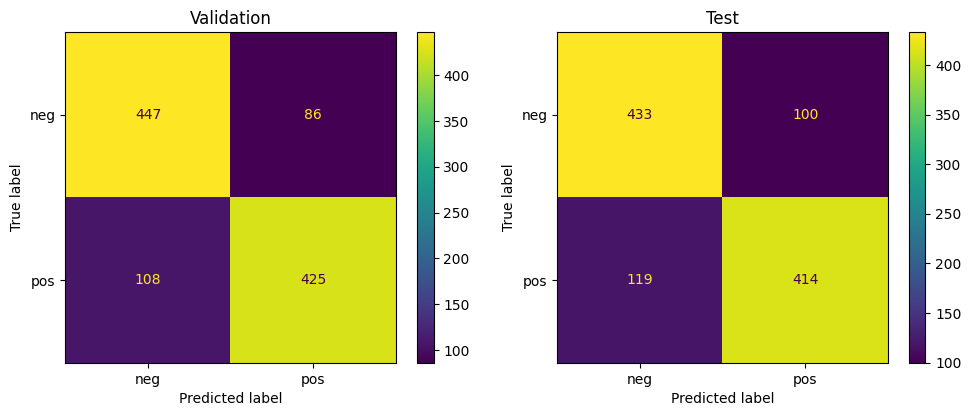

In [ ]:
#NOTA: DA TESTARE ANCHE ALTRO(MLP..)

clf = make_pipeline(StandardScaler(), LinearSVC(max_iter=2000))
clf.fit(X_train, y_train)

for name, X, y in [('validation', X_val, y_val), ('test', X_test, y_test)]:
    preds = clf.predict(X)
    print(f"\n--- {name} ---")
    print(classification_report(y, preds, target_names=['negative', 'positive']))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, X, y) in zip(axes, [('Validation', X_val, y_val), ('Test', X_test, y_test)]):
    ConfusionMatrixDisplay.from_estimator(clf, X, y, display_labels=['neg', 'pos'], ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

---
---
## Exercise 2: Fine-tuning DistilBERT

In this exercise we will fine-tune the DistilBERT model to (hopefully) improve sentiment analysis performance.


---
### Exercise 2.1: Token Preprocessing

The first thing we need to do is *tokenize* our dataset splits -- we don't want to re-tokenize our inputs for every batch! Our current datasets return a dictionary with *strings*, but we want *input token ids* (i.e. the output of the tokenizer). This is easy enough to do by hand, but the Hugging Face `Dataset` class provides convenient, efficient, and *lazy* methods. See the documentation for [`Dataset.map`](https://huggingface.co/docs/datasets/v3.5.0/en/package_reference/main_classes#datasets.Dataset.map).

**Tip**: Verify that your new datasets are returning for every element: `text`, `label`, `intput_ids`, and `attention_mask`.

In [ ]:
def preprocess_function(examples):
    return tokenizer(examples['text'], truncation=True, max_length=512)

tokenized = {}
for split_name, ds in ds_dict.items():
    tokenized[split_name] = ds.map(preprocess_function, batched=True)
    tokenized[split_name].set_format('pt', columns=['input_ids', 'attention_mask'], output_all_columns=True)

tokenized_train = tokenized['train']
tokenized_val   = tokenized['validation']
tokenized_test  = tokenized['test']

# sanity check
print(tokenized_train[0].keys())
print("input_ids:", tokenized_train[0]['input_ids'].shape)

Map:   0%|          | 0/8530 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

dict_keys(['input_ids', 'attention_mask', 'text', 'label', 'token_type_ids'])
input_ids: torch.Size([47])



---
### Exercise 2.2: Setting up the Model to be Fine-tuned

In this exercise we need to prepare the base Distilbert model for fine-tuning for a *sequence classification task*. This means, at the very least, appending a new, randomly-initialized classification head connected to the `[CLS]` token of the last transformer layer. Luckily, HuggingFace already provides an `AutoModel` for just this type of instantiation: [`AutoModelForSequenceClassification`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html#automodelforsequenceclassification). You will want you instantiate one of these for fine-tuning.

In [ ]:
from transformers import AutoModelForSequenceClassification
import torch

cls_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert/distilbert-base-uncased',
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Controlliamo quali parti del modello sono pretrained e quali inizializzate ora
pretrained_layers = [n for n, _ in cls_model.distilbert.named_parameters()]
new_layers = [n for n, _ in cls_model.named_parameters() if not n.startswith('distilbert')]

print("Pretrained backbone layers:", len(pretrained_layers))
print("New classification head layers:", len(new_layers))
print("\nNew layers:")
for n in new_layers:
    print(" ", n)

Pretrained backbone layers: 100
New classification head layers: 4

New layers:
  pre_classifier.weight
  pre_classifier.bias
  classifier.weight
  classifier.bias


In [ ]:
#Testiamo su un solo esempio per vedere se funziona
sample = tokenizer(ds_train[2]['text'], return_tensors='pt', truncation=True, max_length=512)

cls_model.eval()
with torch.no_grad():
    out = cls_model(**sample)

print("Logits:", out.logits)
print("Predicted class:", out.logits.argmax(-1).item(), "| True label:", ds_train[2]['label'])

Logits: tensor([[-0.0548, -0.0314]])
Predicted class: 1 | True label: 1


#### Ha fatto una predizione corretta

In [ ]:
total = sum(p.numel() for p in cls_model.parameters())
head_params = sum(p.numel() for n, p in cls_model.named_parameters() if not n.startswith('distilbert'))
print(f"Total params     : {total:,}")
print(f"Head params      : {head_params:,}  ({100*head_params/total:.2f}%)")
print(f"Backbone params  : {total-head_params:,}  ({100*(total-head_params)/total:.2f}%)")

Total params     : 66,955,010
Head params      : 592,130  (0.88%)
Backbone params  : 66,362,880  (99.12%)


### SOLO lo 0.88% dei parametri del totale verrà addestrato. vediamo se riusciamo a fare meglio del modello baseline del punto precedente


---
### Exercise 2.3: Fine-tuning DistilBERT

Finally. In this exercise you should use a HuggingFace [`Trainer`](https://huggingface.co/docs/transformers/main/en/trainer) to fine-tune your model on the Rotten Tomatoes training split. Setting up the trainer will involve (at least):


1. Instantiating a [`DataCollatorWithPadding`](https://huggingface.co/docs/transformers/en/main_classes/data_collator) object which is what *actually* does your batch construction (by padding all sequences to the same length).
2. Writing an *evaluation function* that will measure the classification accuracy. This function takes a single argument which is a tuple containing `(logits, labels)` which you should use to compute classification accuracy (and maybe other metrics like F1 score, precision, recall) and return a `dict` with these metrics.  
3. Instantiating a [`TrainingArguments`](https://huggingface.co/docs/transformers/v4.51.1/en/main_classes/trainer#transformers.TrainingArguments) object using some reasonable defaults.
4. Instantiating a `Trainer` object using your train and validation splits, you data collator, and function to compute performance metrics.
5. Calling `trainer.train()`, waiting, waiting some more, and then calling `trainer.evaluate()` to see how it did.

**Tip**: When prototyping this laboratory I discovered the HuggingFace [Evaluate library](https://huggingface.co/docs/evaluate/en/index) which provides evaluation metrics. However I found it to have insufferable layers of abstraction and getting actual metrics computed. I suggest just using the Scikit-learn metrics...

In [ ]:
# Your code here.


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! Or if you want to propose something else as a third exercise, reach out to me on the Discord!


---
### Exercise 3.1: Efficient Fine-tuning for Sentiment Analysis

In Exercise 2 we fine-tuned the *entire* Distilbert model on Rotten Tomatoes. This is expensive, even for a small model. Find an *efficient* way to fine-tune Distilbert on the Rotten Tomatoes dataset (or some other dataset).

**Hint**: You could check out the [HuggingFace PEFT library](https://huggingface.co/docs/peft/en/index) for some state-of-the-art approaches that should "just work". How else might you go about making fine-tuning more efficient without having to change your training pipeline from above?

**Why choose this exercise?** PEFT techniques -- especially LoRA are the methods of choice for adapting models to new tasks.

In [ ]:
# Your code here.


---
### Exercise 3.2: Fine-tuning a CLIP Model (harder)

Use a (small) CLIP model like [`openai/clip-vit-base-patch16`](https://huggingface.co/openai/clip-vit-base-patch16) and evaluate its zero-shot performance on a small image classification dataset like ImageNette or TinyImageNet. Fine-tune (using a parameter-efficient method!) the CLIP model to see how much improvement you can squeeze out of it.

**Note**: There are several ways to adapt the CLIP model; you could fine-tune the image encoder, the text encoder, or both. Or, you could experiment with prompt learning.

**Tip**: CLIP probably already works very well on ImageNet and ImageNet-like images. For extra fun, look for an image classification dataset with different image types (e.g. *sketches*).

**Why choose this exercise?** CLIP is probably the most widely used Vision-Language Model, and adapting it is a useful skill to master.

In [ ]:
# Your code here.


---
### Exercise 3.3: A Text-to-image Retrieval System (hard, but not *too* hard)

Implement a simple text-to-image retrieval system with a simple user interface --- using, for example, [gradio](https://www.gradio.app/), or [Marimo](https://marimo.io/), or [Shiny](https://shiny.posit.co/). Your application should *index* (e.g. compute visual descriptors for) a small dataset of images like [Flickr8k](https://huggingface.co/datasets/jxie/flickr8k). It should provide a user interface with which a user can enter a short text prompt (e.g. "a photo of dogs playing in the snow") and then display the top-10 matching images from the indexed dataset.

Note that there is no following code block with "Your code here" for this exercise. You will definitely want to implement this outside of a Jupyter Notebook.

**Hint**: The **CLIP** model is practically *made* for just such an application.

**Why choose this exercise?** Well, this is a course on Deep Learning *Applications*, and this is your chance to *build* one!

---
---